<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/FL_Tree_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Synthetic Data Exchange (Uniform Sampling)

## Goal
We re‑run the **original, simplest version** of the synthetic‑data exchange method – **uniform sampling** between feature min and max – on the **a9a dataset** to establish a baseline.

This is the method from the very first experiment we conducted. We now test it on a9a (larger dataset) and compare with the bootstrap and ensemble results.

## Method
- Clients train local RF on real data.
- Each client generates synthetic data by **uniformly sampling** each feature independently between its min and max, and labelling with the local RF.
- Server aggregates synthetic data and trains a global RF.
- Server generates global synthetic data (uniform) and sends it back to clients (proportional sampling).
- No DP noise, no bootstrap.

## Why This Matters
- This is the simplest possible generator – it assumes features are independent and uniformly distributed.
- It may perform poorly, but it serves as a lower bound for more sophisticated generators.
- It also helps isolate the benefit of bootstrap over uniform sampling.

### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml, load_breast_cancer, fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

In [ ]:
DATASET = 'a9a'
NUM_CLIENTS = 5
NUM_ROUNDS = 10
SAMPLES_PER_CLIENT = 100       # synthetic samples per client per round
SYNTHETIC_SAMPLES_FROM_GLOBAL = 1500  # server pool size
RANDOM_STATE = 42
USE_SCALER = True

print(f"Dataset: {DATASET}, Clients: {NUM_CLIENTS}, Rounds: {NUM_ROUNDS}")
print("Method: Uniform sampling (independent features)")

Dataset: a9a, Clients: 5, Rounds: 10
Method: Uniform sampling (independent features)


### Data Loading

In [ ]:
def load_dataset(name):
    if name == 'breast_cancer':
        data = load_breast_cancer()
        X, y = data.data, data.target
    elif name == 'a9a':
        df, y = fetch_openml(data_id=1590, return_X_y=True, as_frame=True)
        y = (y == '>50K').astype(int).to_numpy()
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns
        X = pd.get_dummies(df, columns=categorical_cols, drop_first=True).to_numpy()
    elif name == 'cod_rna':
        X, y = fetch_openml(data_id=40536, return_X_y=True, as_frame=False)
        y = y.astype(int)
    elif name == 'covertype':
        data = fetch_covtype()
        X, y = data.data, data.target
        y = y - 1
    else:
        raise ValueError(f"Unknown dataset: {name}")
    X, y = shuffle(X, y, random_state=RANDOM_STATE)
    if len(np.unique(y)) == 2:
        y = (y == np.max(y)).astype(int)
    print(f"Loaded {name}: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y

In [ ]:
X, y = load_dataset(DATASET)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

if USE_SCALER:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

Loaded a9a: 48842 samples, 97 features, 2 classes


In [ ]:
# IID split among clients
indices = np.random.permutation(len(X_train))
client_indices = np.array_split(indices, NUM_CLIENTS)
client_real_X = [X_train[idx] for idx in client_indices]
client_real_y = [y_train[idx] for idx in client_indices]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
for i in range(NUM_CLIENTS):
    print(f"  Client {i+1}: {len(client_real_X[i])} real samples")

Training samples: 39073, Test samples: 9769
  Client 1: 7815 real samples
  Client 2: 7815 real samples
  Client 3: 7815 real samples
  Client 4: 7814 real samples
  Client 5: 7814 real samples


### Helper Functions

In [ ]:
def train_rf(X, y):
    """Train a Random Forest classifier."""
    rf = RandomForestClassifier(n_estimators=50,max_depth=5,random_state=RANDOM_STATE,n_jobs=-1)
    rf.fit(X, y)
    return rf

In [ ]:
def generate_synthetic_data_uniform(rf, X_real, num_samples):
    """Generate synthetic data by uniform sampling per feature (independent)."""
    if len(X_real) == 0:
        X_real = X_train

    n_features = X_real.shape[1]
    feature_mins = X_real.min(axis=0)
    feature_maxs = X_real.max(axis=0)

    synthetic_X = np.random.uniform(feature_mins, feature_maxs, size=(num_samples, n_features))
    synthetic_y = rf.predict(synthetic_X)
    return synthetic_X, synthetic_y

In [ ]:
def aggregate_data(client_X_list, client_y_list):
    """Concatenate lists of data from all clients."""
    all_X = np.vstack(client_X_list)
    all_y = np.hstack(client_y_list)
    return all_X, all_y

In [ ]:
def evaluate_model(rf, X_test, y_test):
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    if y_proba.shape[1] == 1:
        auc = 0.5
        loss = 10.0
    else:
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        loss = log_loss(y_test, y_proba)
    return {'accuracy': acc, 'f1': f1, 'auc': auc, 'log_loss': loss}

In [ ]:
# Federated Training with Uniform Sampling
def run_federated_uniform(noise_std=None, samples_per_client=SAMPLES_PER_CLIENT, num_rounds=NUM_ROUNDS):
    """Uniform sampling version (no noise added)."""
    client_synthetic_X = [[] for _ in range(NUM_CLIENTS)]
    client_synthetic_y = [[] for _ in range(NUM_CLIENTS)]

    round_accuracies = []
    round_f1 = []
    round_auc = []
    round_logloss = []

    for round_idx in range(num_rounds):
        # 1. Local training
        client_rfs = []
        for client_id in range(NUM_CLIENTS):
            if len(client_synthetic_X[client_id]) > 0:
                X_client = np.vstack([client_real_X[client_id], client_synthetic_X[client_id]])
                y_client = np.hstack([client_real_y[client_id], client_synthetic_y[client_id]])
            else:
                X_client = client_real_X[client_id]
                y_client = client_real_y[client_id]
            rf = train_rf(X_client, y_client)
            client_rfs.append(rf)

        # 2. Client generates synthetic data (uniform)
        all_synthetic_X = []
        all_synthetic_y = []
        for client_id in range(NUM_CLIENTS):
            if len(client_synthetic_X[client_id]) > 0:
                combined_X = np.vstack([client_real_X[client_id], client_synthetic_X[client_id]])
            else:
                combined_X = client_real_X[client_id]
            synth_X, synth_y = generate_synthetic_data_uniform(
                client_rfs[client_id], combined_X, samples_per_client
            )
            all_synthetic_X.append(synth_X)
            all_synthetic_y.append(synth_y)

        # 3. Server aggregation
        global_X, global_y = aggregate_data(all_synthetic_X, all_synthetic_y)

        # 4. Train global RF
        global_rf = train_rf(global_X, global_y)
        met = evaluate_model(global_rf, X_test, y_test)
        round_accuracies.append(met['accuracy'])
        round_f1.append(met['f1'])
        round_auc.append(met['auc'])
        round_logloss.append(met['log_loss'])

        # 5. Server generates global synthetic pool (uniform)
        server_pool_X, server_pool_y = generate_synthetic_data_uniform(
            global_rf, global_X, SYNTHETIC_SAMPLES_FROM_GLOBAL
        )
        # Proportional sampling
        total_real_samples = sum(len(cX) for cX in client_real_X)
        for client_id in range(NUM_CLIENTS):
            prop = len(client_real_X[client_id]) / total_real_samples
            sample_size = max(1, int(prop * SYNTHETIC_SAMPLES_FROM_GLOBAL))
            idx = np.random.choice(len(server_pool_X), sample_size, replace=False)
            client_synthetic_X[client_id] = server_pool_X[idx].copy()
            client_synthetic_y[client_id] = server_pool_y[idx].copy()

    return {
        'accuracy': round_accuracies,
        'f1': round_f1,
        'auc': round_auc,
        'log_loss': round_logloss
    }

### Training

In [ ]:
# Centralized baseline
central_rf = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE)
central_rf.fit(X_train, y_train)
central_metrics = {
    'accuracy': accuracy_score(y_test, central_rf.predict(X_test)),
    'f1': f1_score(y_test, central_rf.predict(X_test), average='weighted'),
    'auc': roc_auc_score(y_test, central_rf.predict_proba(X_test)[:, 1]),
    'log_loss': log_loss(y_test, central_rf.predict_proba(X_test))
}
print(f"Centralized baseline accuracy: {central_metrics['accuracy']:.4f}")

Centralized baseline accuracy: 0.8521


In [ ]:
print("\nRunning Federated Training with Uniform Sampling")
results_uniform = run_federated_uniform()

print(f"\nFinal Global RF accuracy: {results_uniform['accuracy'][-1]:.4f}")
print(f"Centralized baseline: {central_metrics['accuracy']:.4f}")
print(f"Gap to centralised: {central_metrics['accuracy'] - results_uniform['accuracy'][-1]:.4f}")


Running Federated Training with Uniform Sampling

Final Global RF accuracy: 0.2311
Centralized baseline: 0.8521
Gap to centralised: 0.6209


## Results Visualisation

We plot the global RF accuracy over rounds for uniform sampling, and compare with the centralised baseline.

In [ ]:
# Cell 7: Summary Table
print("\n" + "="*25)
print("SUMMARY – UNIFORM SAMPLING")
print("="*25)
final_met = {
    'accuracy': results_uniform['accuracy'][-1],
    'f1': results_uniform['f1'][-1],
    'auc': results_uniform['auc'][-1],
    'log_loss': results_uniform['log_loss'][-1]
}
print(f"Uniform Global RF:")
print(f"  Accuracy: {final_met['accuracy']:.4f}")
print(f"  F1:       {final_met['f1']:.4f}")
print(f"  AUC:      {final_met['auc']:.4f}")
print(f"  Log Loss: {final_met['log_loss']:.4f}")
print(f"\nCentralized baseline:")
print(f"  Accuracy: {central_metrics['accuracy']:.4f}")
print(f"  Gap:      {central_metrics['accuracy'] - final_met['accuracy']:.4f}")
print("="*25)


SUMMARY – UNIFORM SAMPLING
Uniform Global RF:
  Accuracy: 0.2311
  F1:       0.0868
  AUC:      0.5000
  Log Loss: 10.0000

Centralized baseline:
  Accuracy: 0.8521
  Gap:      0.6209


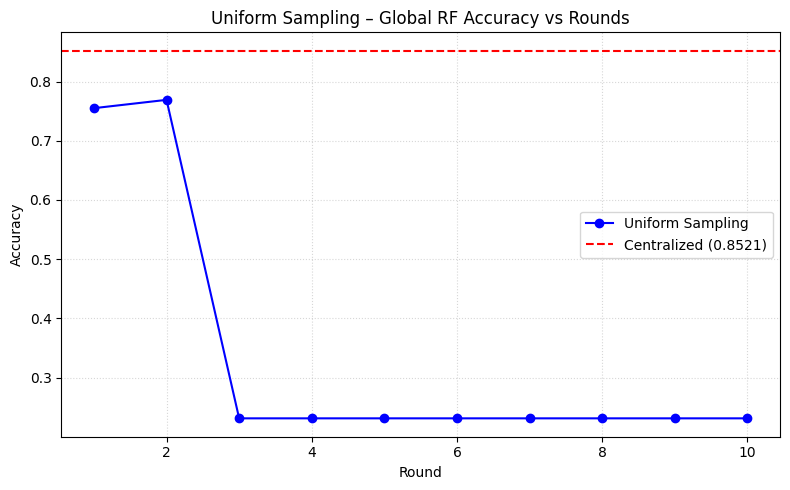

In [ ]:
# Cell 6: Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_ROUNDS+1), results_uniform['accuracy'],
         marker='o', label='Uniform Sampling', color='blue')
plt.axhline(y=central_metrics['accuracy'], color='red', linestyle='--',
            label=f'Centralized ({central_metrics["accuracy"]:.4f})')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.title('Uniform Sampling – Global RF Accuracy vs Rounds')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('uniform_sampling_a9a.png', dpi=150)
plt.show()

# Conclusion – Uniform Sampling on a9a

## What Did We Do?

We re‑ran the **simplest possible synthetic data generation method** – **uniform sampling** – on the a9a dataset. Each client sampled synthetic features independently from the min‑max range of its real data, labelled them with its local RF, and uploaded them to the server. The server then trained a global RF on the aggregated synthetic data.

This is the most naive generator: it assumes all features are independent and uniformly distributed, which is rarely true in real data.

---

## Results

| Metric | Uniform Sampling (Global RF) | Centralised Baseline | Gap |
|--------|------------------------------|----------------------|-----|
| **Accuracy** | 0.2311 | 0.8521 | **0.6209** |
| **F1** | 0.0868 | 0.8358 | 0.7490 |
| **AUC** | 0.5000 | 0.9091 | 0.4091 |
| **Log Loss** | 10.0000 | 0.3512 | 9.6488 |

---

## Interpretation

### 1. Complete Failure
- **AUC = 0.5** – the model is performing **no better than random guessing**.
- **Log Loss = 10.0** – the model is severely miscalibrated.
- **Accuracy = 23.11%** – barely above the dataset's class imbalance baseline (≈25% for the minority class in a9a).

### 2. Why Did It Fail?
- **Independence assumption**: Features in real tabular data are **correlated**. Uniform sampling treats each feature independently, destroying these correlations.
- **Uniformity assumption**: Real features are rarely uniformly distributed – they often have complex multimodal distributions (e.g., income, age).
- **Synthetic‑only training**: The global model is trained **only** on this unrealistic synthetic data, so it learns a completely wrong decision boundary.

### 3. Comparison with Other Methods

| Method | Accuracy | AUC | Log Loss | Gap to Centralised |
|--------|----------|-----|----------|-------------------|
| **Uniform Sampling** | 0.2311 | 0.5000 | 10.0000 | 0.6209 |
| **Bootstrap** | 0.7689 | 0.5000 | 10.0000 | 0.0832 |
| **Bootstrap + Ensemble** | **0.8486** | **0.9091** | **0.3553** | **0.0035** |

- **Uniform Sampling** is the worst performer by a large margin.
- **Bootstrap** significantly improves accuracy by preserving the empirical distribution (but still has calibration issues).
- **Ensemble** almost closes the gap completely by using models trained on real data.

---

## Key Takeaway

| Finding | Implication |
|---------|-------------|
| Uniform sampling fails completely | **Feature correlations matter** – they cannot be ignored. |
| Bootstrap improves dramatically | **Preserving the empirical distribution** is critical for synthetic data quality. |
| Ensemble almost matches centralised | The bottleneck is **synthetic‑only global training**, not the synthetic data itself. |

---

## Final Verdict

- **Uniform sampling is not suitable** for this paradigm – it produces unrealistic data that destroys the model's ability to learn.
- **Bootstrap** is a much better choice because it preserves the empirical distribution and feature correlations.
- **Ensemble voting** is the best approach overall, as it avoids synthetic‑only training entirely and achieves near‑centralised performance.

**This experiment serves as a lower bound** – it shows how badly simple generators can perform, and justifies the need for more sophisticated methods like bootstrap and ensemble.